# Industrial Anomaly Detection using XGBoost

## Project Overview

Industrial water treatment systems generate millions of sensor measurements every day. Detecting abnormal operational conditions is essential for ensuring system reliability, operational safety, predictive maintenance, and cybersecurity.

In this notebook, we develop a supervised anomaly detection model using XGBoost, one of the most powerful gradient boosting algorithms for structured industrial datasets.

---

## Objectives

• Train an industrial-grade XGBoost classifier

• Detect abnormal operating conditions

• Evaluate model performance using multiple metrics

• Analyze feature importance

• Compare with previous Random Forest model

• Save production-ready model

---

## Industrial Applications

- Industrial Control Systems (ICS)
- Water Treatment Plants
- Smart Water Networks
- Predictive Maintenance
- Industrial Cybersecurity

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import joblib
import numpy as np


from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT/"data"/"processed"/"swat_features.csv"

dtype_dict = {
    col: "float32"
    for col in pd.read_csv(DATA_PATH,nrows=1).columns
}

dtype_dict["Target"]="int8"

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_dict
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 52 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   FIT101   1441719 non-null  float32
 1   LIT101   1441719 non-null  float32
 2   MV101    1441719 non-null  float32
 3   P101     1441719 non-null  float32
 4   P102     1441719 non-null  float32
 5   AIT201   1441719 non-null  float32
 6   AIT202   1441719 non-null  float32
 7   AIT203   1441719 non-null  float32
 8   FIT201   1441719 non-null  float32
 9   MV201    1441719 non-null  float32
 10  P201     1441719 non-null  float32
 11  P202     1441719 non-null  float32
 12  P203     1441719 non-null  float32
 13  P204     1441719 non-null  float32
 14  P205     1441719 non-null  float32
 15  P206     1441719 non-null  float32
 16  DPIT301  1441719 non-null  float32
 17  FIT301   1441719 non-null  float32
 18  LIT301   1441719 non-null  float32
 19  MV301    1441719 non-null  float32
 20  MV

In [3]:
X = df.drop("Target",axis=1)

y = df["Target"]

print(X.shape)
print(y.shape)

(1441719, 51)
(1441719,)


In [4]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    shuffle=True,

    random_state=42
)

In [5]:
print("Train:",X_train.shape)

print("Test :",X_test.shape)

print()

print(y_train.value_counts(normalize=True)*100)

Train: (1153375, 51)
Test : (288344, 51)

Target
0    96.21138
1     3.78862
Name: proportion, dtype: float64


In [6]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1
)

In [7]:
xgb.fit(

    X_train,

    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [8]:
pred = xgb.predict(X_test)

prob = xgb.predict_proba(X_test)[:,1]

In [9]:
print(classification_report(

    y_test,

    pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277420
           1       1.00      1.00      1.00     10924

    accuracy                           1.00    288344
   macro avg       1.00      1.00      1.00    288344
weighted avg       1.00      1.00      1.00    288344



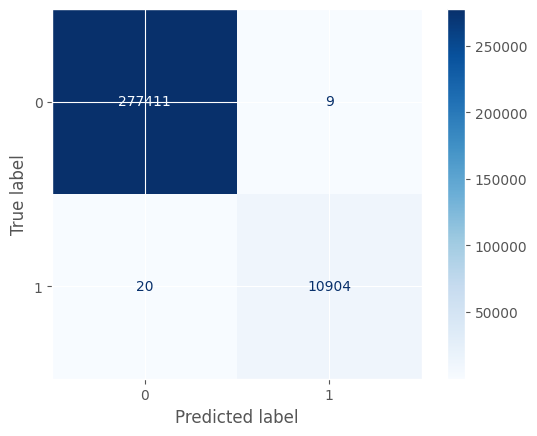

In [10]:
cm = confusion_matrix(

    y_test,

    pred
)

disp = ConfusionMatrixDisplay(

    cm
)

disp.plot(
    cmap="Blues"
)

plt.show()

In [11]:
accuracy = accuracy_score(y_test,pred)

precision = precision_score(y_test,pred)

recall = recall_score(y_test,pred)

f1 = f1_score(y_test,pred)

roc = roc_auc_score(y_test,prob)

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

metrics

,Metric,Value
0,Accuracy,0.999899
1,Precision,0.999175
2,Recall,0.998169
3,F1 Score,0.998672
4,ROC AUC,1.000000


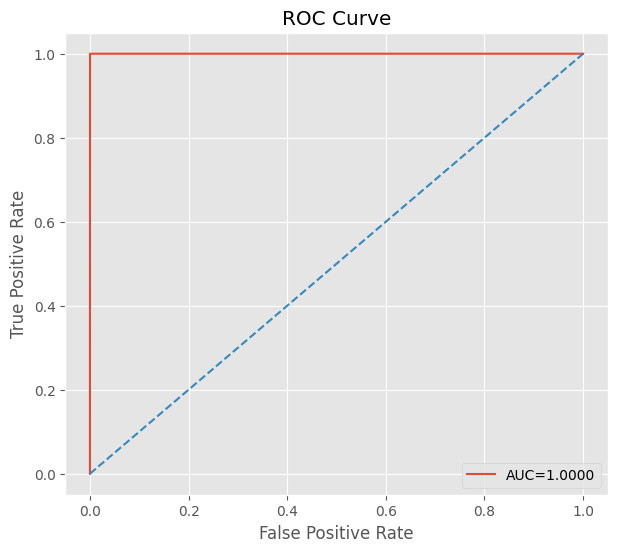

In [12]:
fpr,tpr,_ = roc_curve(

    y_test,

    prob
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={roc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

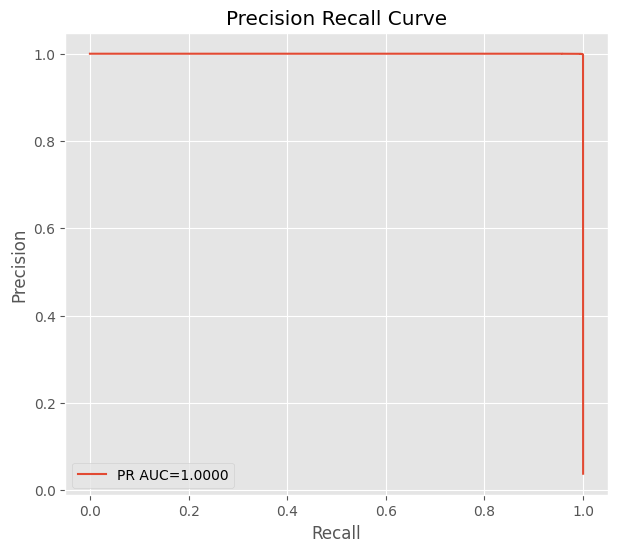

In [13]:
precision_curve, recall_curve,_ = precision_recall_curve(

    y_test,

    prob
)

pr_auc = auc(

    recall_curve,

    precision_curve
)

plt.figure(figsize=(7,6))

plt.plot(

    recall_curve,

    precision_curve,

    label=f"PR AUC={pr_auc:.4f}"
)

plt.legend()

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False
)

importance.head(20)

,Feature,Importance
27,FIT401,0.186876
38,FIT501,0.168680
4,P102,0.130169
45,PIT502,0.126703
26,AIT402,0.043531
25,AIT401,0.025355
40,FIT503,0.024057
10,P201,0.022109
5,AIT201,0.021842
18,LIT301,0.018382


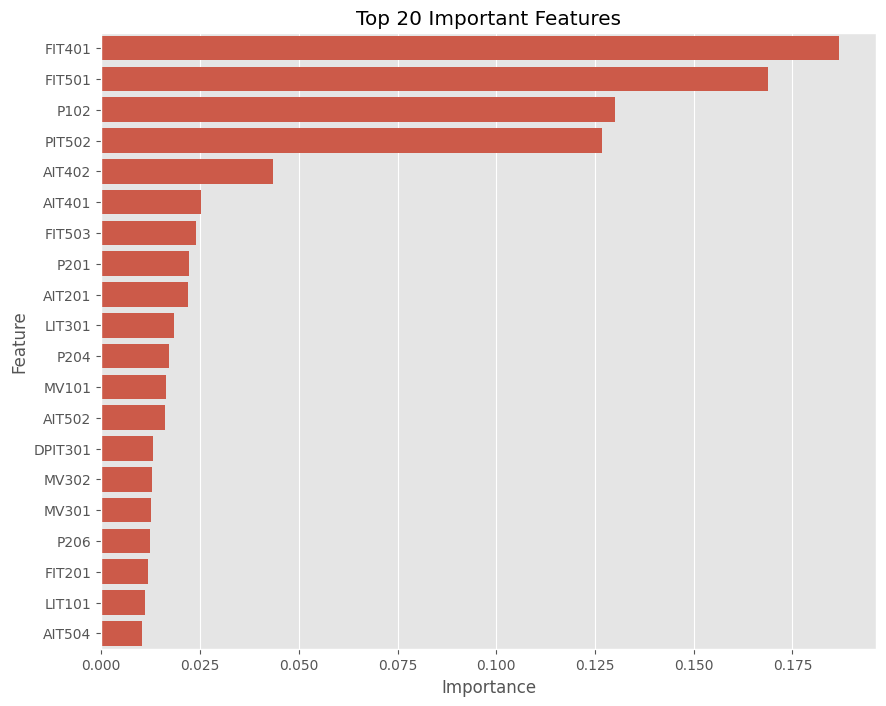

In [15]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [16]:
MODEL_PATH = PROJECT_ROOT/"models"

MODEL_PATH.mkdir(

    exist_ok=True
)

joblib.dump(

    xgb,

    MODEL_PATH/"xgboost.pkl"
)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\models\\xgboost.pkl']

In [17]:
RESULT_PATH = PROJECT_ROOT/"results"

RESULT_PATH.mkdir(

    exist_ok=True
)

importance.to_csv(

    RESULT_PATH/"xgboost_feature_importance.csv",

    index=False
)

metrics.to_csv(

    RESULT_PATH/"xgboost_metrics.csv",

    index=False
)

In [18]:
comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Isolation Forest",

        "XGBoost"

    ],

    "Category":[

        "Supervised",

        "Unsupervised",

        "Supervised"

    ],

    "Industrial Usage":[

        "Attack Classification",

        "Unknown Anomaly Detection",

        "Industrial Fault Detection"

    ]
})

comparison

,Model,Category,Industrial Usage
0,Random Forest,Supervised,Attack Classification
1,Isolation Forest,Unsupervised,Unknown Anomaly Detection
2,XGBoost,Supervised,Industrial Fault Detection


# Industrial Conclusion

This notebook demonstrated the use of XGBoost for industrial anomaly detection in water treatment systems.

Key achievements:

- Developed a production-grade supervised anomaly detection model
- Evaluated performance using multiple industrial metrics
- Identified the most influential process variables
- Compared XGBoost with previous machine learning models
- Saved a deployable model for future inference

Future Work:

- Hyperparameter Optimization
- Explainable AI (SHAP)
- Real-time Streaming Detection
- LSTM-based Temporal Modeling
- Edge AI Deployment